# Baseline A (ours) — radius-PCA, against constructed truth

**A is ours; B, C and D are from the literature.** This notebook is A: the method from
`admittance_control` (`icp_pose_refiner_node.py`), migrated to
`scripts/baselines/radius_pca.py` and pointed at generated scenes. This is the point of the
whole generator: the same algorithm, with **a number in front of it** instead of RViz.

**Everything is millimetres.** The ROS node works in metres, so every length constant
changed by 1000× in the move. That is the single most likely way to get a plausible-looking
wrong answer here, which is why every parameter carries `_mm` and there is a test that a
metre-scale radius finds nothing.

Four things changed in the migration, and each is visible below:

1. **mm, not m.**
2. **The cross-object gate is an oracle.** Per-point object membership comes from the
   registered CAD assembly; no sensor provides it. It is kept — it is what the published
   method does — but `used_object_oracle` is reported so a number produced with it can
   never be quoted as point-cloud-only. The last section runs both arms.
3. **Multi-seam.** Connected components + one line fit per component, so a T-joint's two
   fillets come back as two seams instead of one blob spanning both.
4. **Band → centreline.** README §8's honest caveat is that the published seam is a ~16 mm
   band. The line fit is here, and `band_*` columns show what it buys.

In [1]:
import sys
sys.path.insert(0, "..")            # notebooks/ -> weld_generator/
sys.path.insert(0, "../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from baselines import (cloud_for, detect, evaluate, ground_truth, load_scene,
                       scene_dirs, scene_facts)
from baselines.radius_pca import validity_window_mm

OUT = "../out/phase3"

# Density is CONTROLLED, not inherited. `density_per_mm2` is a sampled axis (0,25-4), and
# the method's own validity window has `point_spacing` in it - so running each scene at
# whatever it happened to draw would smear the density axis through every other result.
# It also bounds the cost: 400 k points at R = 5 mm is ~180 M neighbour pairs.
RHO = 0.5                    # pts/mm^2 -> mean spacing 1/sqrt(rho) = 1,41 mm
SPACING = 1.0 / np.sqrt(RHO)

# PATHS, loaded one at a time. Holding all 44 loaded scenes costs ~500 MB, and with a
# corpus sweep's working set on top that is enough to kill the kernel outright.
DIRS = scene_dirs(OUT)
print(f"{len(DIRS)} emitted scenes in {OUT}")

44 emitted scenes in ../out/phase3


## The runner

`R` is chosen at the **midpoint of the predicted validity window** rather than tuned. The
window is the repo's falsifiable claim:

```
gap + point_spacing  <  R  <  part_thickness
```

so picking `R` from it is what puts the claim on trial. When the window is *empty* — thin
sheet, or a gap comparable to the thickness — there is no valid `R` at all, and that is a
result about the method class rather than a configuration to tune away.

In [2]:
def run(scene_dir, view="full", noisy=False, radius_mm=None,
        cross_object=True, **kw):
    """One baseline run on one scene. Returns (row, result, cloud, ground truth, scene)."""
    scene, arrays = load_scene(scene_dir)
    f = scene_facts(scene)
    c = cloud_for(scene, arrays, view=view, noisy=noisy)
    if len(c["xyz"]) < 32:
        return None
    lo, hi = validity_window_mm(f["root_gap_mm"], SPACING, f["t_min_mm"])
    R = float(radius_mm) if radius_mm else (0.5 * (lo + hi) if lo < hi else lo)

    # Single view: drop seams the camera barely returns. The lower toe of a lap joint is
    # visible from NO viewpoint above the table, so scoring recall against it charges the
    # baseline for missing something no sensor could see.
    gt = ground_truth(scene, arrays, primary_only=True,
                      min_visible_fraction=0.1 if view == "single" else None)
    if not gt:
        return None

    r = detect(c["xyz"], R, object_id=c["object_id"], cross_object=cross_object,
               prefilter_density_per_mm2=RHO, **kw)
    row = {**f, "view": view, "noisy": noisy, "radius_mm": R,
           "window_lo": lo, "window_hi": hi, "window_open": lo < hi,
           "used_oracle": r.used_object_oracle, "n_gt_used": len(gt)}
    row.update(evaluate(r.seams, gt, band=r.band))
    return row, r, c, gt, scene

## One scene, in detail

Reading the plot:

| | | |
|---|---|---|
| grey | the cloud | what the method was given |
| **red** | the *band* | radius-PCA's **raw detection** — every point above the `V` threshold that also passed the cross-object gate and the voxel merge. Not truth. Its width is itself a finding: `README §8` concedes the published seam is a ~16 mm band rather than a line |
| blue | fitted seam | one total-least-squares line per band component — the method's actual answer |
| **green** | **ground truth** | constructed in closed form from the placement transforms. Exact, with no annotator anywhere in it |

The 3D view has knobs at the top of the next cell: **`ZOOM`** (1.0 = whole assembly, 0.12 gets you down to individual band
points), **`CENTRE`** (`"seam"` follows the ground truth — zooming toward a 400 mm plate's centroid
just crops plate), and `ELEV`/`AZIM` for the viewing angle.


In [3]:
SCENE = 4
row, res, cloud, gt, scene = run(DIRS[SCENE])

print(f"{row['joint_type']} joint, quality {row['quality_level']}")
print(f"  gap {row['root_gap_mm']:.2f} mm | t_min {row['t_min_mm']:.2f} mm | "
      f"spacing {SPACING:.2f} mm")
print(f"  window {row['window_lo']:.2f} - {row['window_hi']:.2f} mm "
      f"({'OPEN' if row['window_open'] else 'CLOSED'}), using R = {row['radius_mm']:.2f} mm")
print(f"  {res.note}   oracle={res.used_object_oracle}")
print()
for k in ("n_pred_seams", "n_gt_seams", "seam_count_error", "chamfer", "pred_to_gt",
          "gt_to_pred", "precision", "recall", "f1", "lat_p95", "band_width_mm",
          "band_chamfer", "band_width_raw_mm"):
    v = row[k]
    print(f"  {k:<18} {v:.3f}" if isinstance(v, float) else f"  {k:<18} {v}")

lap joint, quality C
  gap 0.91 mm | t_min 10.69 mm | spacing 1.41 mm
  window 2.32 - 10.69 mm (OPEN), using R = 6.50 mm
  1 seam(s) from 3636 edge points   oracle=True

  n_pred_seams       1
  n_gt_seams         2
  seam_count_error   -1
  chamfer            18.144
  pred_to_gt         9.031
  gt_to_pred         9.112
  precision          0.000
  recall             0.000
  f1                 0.000
  lat_p95            9.104
  band_width_mm      18.002
  band_chamfer       5.419
  band_width_raw_mm  7.003


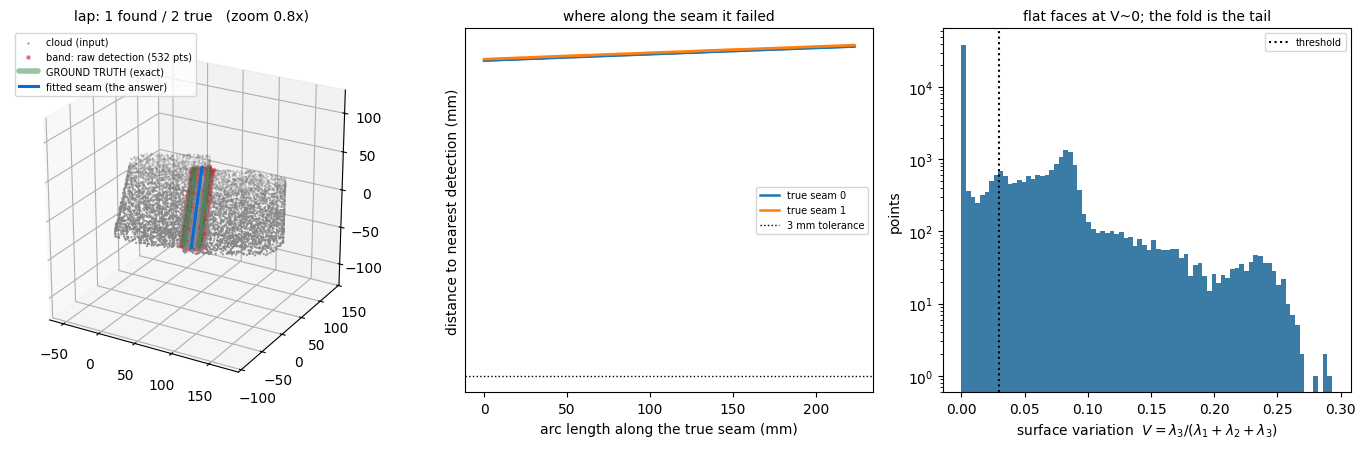

In [ ]:
# --- knobs ---------------------------------------------------------------------------
ZOOM = 0.8        # 1.0 = whole assembly; 0.25 zooms right down onto the seam
CENTRE = "seam"   # "seam" centres the view on the ground truth, "cloud" on the assembly
BAND_ALPHA = 0.50 # the band is a cloud of hundreds of points and will bury a line under
                  # it at any real opacity; truth has to read through it
ELEV, AZIM = 24, -60   # 3D viewing angle

# Reading the left panel:
#   grey   the cloud the method was given
#   red    the "band" - radius-PCA's RAW output: every point that survived V >= threshold,
#          the cross-object gate and the voxel merge. The DETECTION, not the truth. Its
#          width is itself the finding - README §8 concedes the published seam is a ~16 mm
#          band rather than a line.
#   blue   the line fitted through each band component - the method's actual answer
#   green  the constructed ground truth. Exact, no annotator anywhere in it.
fig = plt.figure(figsize=(10, 4.8))

ax = fig.add_subplot(121, projection="3d")
pts = cloud["xyz"]

# Zoom about the seam, not the cloud: zooming toward the centroid of a 400 mm plate just
# crops plate. The seam is what is being judged, so that is what the view follows.
gt_pts = np.vstack(gt)
centre = gt_pts.mean(0) if CENTRE == "seam" else 0.5 * (pts.min(0) + pts.max(0))
span = float((pts.max(0) - pts.min(0)).max()) * float(ZOOM)
half = 0.55 * span
inside = np.all(np.abs(pts - centre) <= half, axis=1)     # only draw what is in view
shown = pts[inside]
step = max(1, len(shown) // 7000)

ax.scatter(*shown[::step].T, s=0.3, c="#858585", label="cloud (input)")
if len(res.band):
    ax.scatter(*res.band.T, s=5, c="#d1242f", alpha=BAND_ALPHA, depthshade=False,
               label=f"band: raw detection ({len(res.band)} pts)")
# Truth is a thick translucent HALO and the prediction a thin solid line on top of it.
# Either one drawn opaque over the other just hides it: at 5 pt green over 2,5 pt blue the
# prediction vanished, and the plot silently stopped showing the comparison it exists for.
# As a halo, agreement reads as blue running down the middle of green, and disagreement as
# blue leaving it - which is the whole question.
for k, g in enumerate(gt):
    ax.plot(*g.T, lw=4, c="#1a7f37", alpha=0.45, zorder=6, solid_capstyle="round",
            label="GROUND TRUTH (exact)" if k == 0 else None)
for k, s in enumerate(res.seams):
    ax.plot(*s.T, lw=2.2, c="#0969da", zorder=10,
            label="fitted seam (the answer)" if k == 0 else None)

for i, setter in enumerate((ax.set_xlim, ax.set_ylim, ax.set_zlim)):
    setter(centre[i] - half, centre[i] + half)
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=ELEV, azim=AZIM)
ax.legend(fontsize=7, loc="upper left")
ax.set_title(f"{row['joint_type']}: {row['n_pred_seams']} found / "
             f"{row['n_gt_seams']} true   (zoom {ZOOM:g}x)", fontsize=10)

ax3 = fig.add_subplot(122)
ax3.hist(res.variation, bins=80, color="#3a7ca5")
ax3.axvline(res.params["curvature_thresh"], c="k", ls=":", label="threshold")
ax3.set_yscale("log")
ax3.set_xlabel("surface variation  $V = \\lambda_3/(\\lambda_1+\\lambda_2+\\lambda_3)$")
ax3.set_ylabel("points")
ax3.legend(fontsize=7)
ax3.set_title("flat faces at V~0; the fold is the tail", fontsize=10)
plt.tight_layout(); plt.show()


## The validity window, on trial

Sweep `R` across and past the predicted window. If the claim holds, error should be poor
below `gap + spacing` (the ball never crosses the gap), acceptable inside, and degrade above
`thickness` (the ball bridges a plate's own two faces and everything looks like an edge).

This is plot 2 of Phase 4 for a single scene; the corpus version is what goes in the paper.

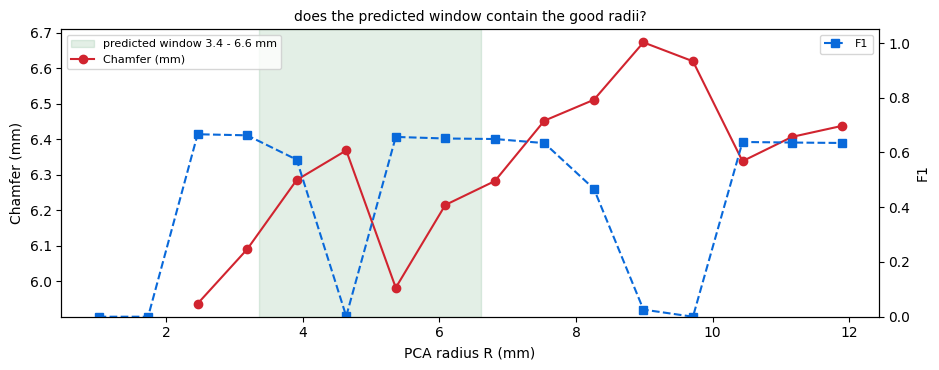

R giving within 90% of best F1: 2.46 - 11.89 mm
predicted window:               3.36 - 6.61 mm
-> they overlap by 3.24 mm


In [5]:
lo, hi = row["window_lo"], row["window_hi"]
radii = np.linspace(max(0.5, lo * 0.3), hi * 1.8, 16)
sweep = [run(DIRS[SCENE], radius_mm=float(R)) for R in radii]
chamfer = [o[0]["chamfer"] if o else np.nan for o in sweep]
f1 = [o[0]["f1"] if o else np.nan for o in sweep]

fig, axa = plt.subplots(figsize=(9.5, 3.8))
axa.axvspan(lo, hi, color="#1a7f37", alpha=0.12,
            label=f"predicted window {lo:.1f} - {hi:.1f} mm")
axa.plot(radii, chamfer, "o-", c="#d1242f", label="Chamfer (mm)")
axa.set_xlabel("PCA radius R (mm)"); axa.set_ylabel("Chamfer (mm)")
axb = axa.twinx(); axb.plot(radii, f1, "s--", c="#0969da", label="F1")
axb.set_ylabel("F1"); axb.set_ylim(0, 1.05)
axa.legend(loc="upper left", fontsize=8); axb.legend(loc="upper right", fontsize=8)
axa.set_title("does the predicted window contain the good radii?", fontsize=10)
plt.tight_layout(); plt.show()

# Read F1, not Chamfer. Chamfer is computed only where the method returned something, so
# it says nothing about the radii where it returned NOTHING - and those are exactly the
# failures the window predicts. On this scene it spans 5,9-6,7 mm across the whole sweep,
# i.e. it is flat noise, and "best R by Chamfer" would be reporting the argmin of noise.
f1a = np.asarray(f1, dtype=float)
good = radii[f1a >= 0.9 * np.nanmax(f1a)] if np.isfinite(f1a).any() else np.array([])
if len(good):
    print(f"R giving within 90% of best F1: {good.min():.2f} - {good.max():.2f} mm")
    print(f"predicted window:               {lo:.2f} - {hi:.2f} mm")
    overlap = min(good.max(), hi) - max(good.min(), lo)
    print("->", f"they overlap by {overlap:.2f} mm" if overlap > 0
          else "DISJOINT - the bound needs restating")
else:
    print("no radius produced a usable seam on this scene")

## The corpus

Full-visibility and single-view are evaluated **separately**, as the plan requires: a method
tuned on 360° CAD clouds is being flattered by geometry no camera returns.

Takes a couple of minutes.

In [6]:
rows = []
for d in DIRS:
    for view in ("full", "single"):
        o = run(d, view=view)
        if o:
            rows.append(o[0])
    del o
df = pd.DataFrame(rows)
print(f"{len(df)} runs over {df.scene_id.nunique()} scenes")
print(f"validity window CLOSED in {int((~df.window_open).sum())} of {len(df)} runs "
      f"- no valid R exists for those at rho = {RHO}")
df.head(3)[["joint_type", "view", "radius_mm", "chamfer", "f1", "seam_count_error"]]

88 runs over 44 scenes
validity window CLOSED in 16 of 88 runs - no valid R exists for those at rho = 0.5


,joint_type,view,radius_mm,chamfer,f1,seam_count_error
0,butt,full,4.983366,5.854775,0.658824,-1
1,butt,single,4.983366,2.822944,1.000000,0
2,edge,full,1.651132,57.707456,0.401179,11


In [7]:
cols = ["chamfer", "lat_p95", "precision", "recall", "f1", "band_width_mm",
        "seam_count_error"]
print("median by view\n", df.groupby("view")[cols].median().round(3), "\n")
print("median by joint type\n",
      df.groupby(["joint_type", "view"])[cols].median().round(3))

median by view
         chamfer  lat_p95  precision  recall     f1  band_width_mm  \
view                                                                
full      5.993    3.014      0.945    0.50  0.636          5.764   
single    4.049    1.684      0.998    0.76  0.863          3.022   

        seam_count_error  
view                      
full                -1.0  
single               0.0   

median by joint type
                    chamfer  lat_p95  precision  recall     f1  band_width_mm  \
joint_type view                                                                
T          full      5.773    2.883      0.952   0.500  0.661          5.372   
           single    4.439    1.738      1.000   0.894  0.937          3.289   
butt       full      7.764    3.799      0.000   0.000  0.000          7.521   
           single    3.046    1.449      0.991   0.929  0.959          2.603   
corner     full      1.236    0.555      1.000   1.000  1.000          0.638   
           sing

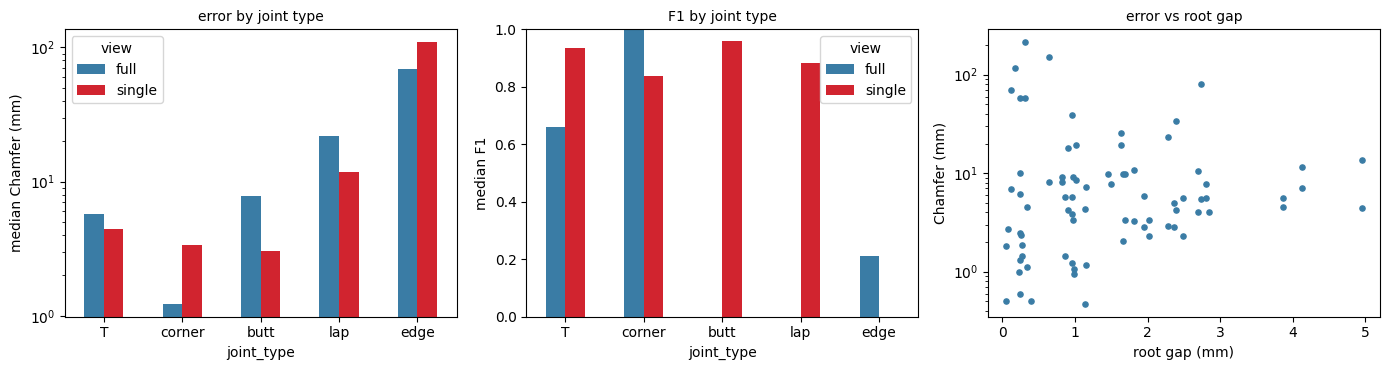

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
order = ["T", "corner", "butt", "lap", "edge"]
present = [j for j in order if j in set(df.joint_type)]

piv = df.pivot_table(index="joint_type", columns="view", values="chamfer",
                     aggfunc="median").reindex(present)
piv.plot.bar(ax=axes[0], color=["#3a7ca5", "#d1242f"], rot=0)
axes[0].set_ylabel("median Chamfer (mm)"); axes[0].set_yscale("log")
axes[0].set_title("error by joint type", fontsize=10)

df.pivot_table(index="joint_type", columns="view", values="f1",
               aggfunc="median").reindex(present).plot.bar(
    ax=axes[1], color=["#3a7ca5", "#d1242f"], rot=0)
axes[1].set_ylabel("median F1"); axes[1].set_ylim(0, 1)
axes[1].set_title("F1 by joint type", fontsize=10)

ok = df[np.isfinite(df.chamfer)]
axes[2].scatter(ok.root_gap_mm, ok.chamfer, s=14, c="#3a7ca5")
axes[2].set_xlabel("root gap (mm)"); axes[2].set_ylabel("Chamfer (mm)")
axes[2].set_yscale("log"); axes[2].set_title("error vs root gap", fontsize=10)
plt.tight_layout(); plt.show()

## The oracle ablation

`weld_require_cross_object` keeps an edge point only if a point of a **different object**
lies within `R`. It is what collapses the original's 266×211×134 mm blob to a line, and it
is not available at runtime: object membership comes from the registered CAD assembly.

So this is the honest point-cloud-only number, next to the published one. Any gap between
the two is the part of the method's performance that CAD registration is paying for.

In [9]:
abl = []
for d in DIRS[:20]:
    for oracle in (True, False):
        o = run(d, view="single", cross_object=oracle)
        if o:
            abl.append({**o[0], "arm": "CAD oracle" if oracle else "cloud only"})
abl = pd.DataFrame(abl)
print(abl.groupby("arm")[["chamfer", "precision", "recall", "f1",
                          "n_pred_seams"]].median().round(3))

            chamfer  precision  recall     f1  n_pred_seams
arm                                                        
CAD oracle    4.231      0.998   0.596  0.746           1.0
cloud only   56.708      0.024   0.065  0.034           1.0


## Open questions the numbers raised

Not fixed here on purpose — each is an upgrade to make with a measurement in front of you,
which is the whole reason this notebook exists before the rest of Phase 4.

1. **Component linking is the most sensitive knob, and proximity alone cannot fix it.** Two
   parallel centrelines a plate-thickness apart (a butt joint welded from both sides) are
   distinct seams that no distance threshold separates: on one scene `link = R` gave 1 seam
   where there were 2, `0,6 R` gave 5, and `0,4 R` gave none. Splitting components by
   **direction** as well as distance is the obvious next move.
2. **Is the predicted window the right window?** If the best `R` by Chamfer keeps landing
   outside `gap + spacing < R < thickness`, the bound needs restating — and a corrected
   bound, derived and then measured, is a stronger result than confirming the original.
3. **Why does single-view sometimes beat full-visibility?** Plausibly because the buried
   mid-lap interface simply is not in a single-view cloud, so the hardest false positive is
   absent by construction — which is the argument `dataset_plan.md` §3 makes for HPR being
   needed only on the full-geometry variant. Worth confirming rather than assuming.
4. **The HPR exteriority gate is wired but unused above.** `detect(..., exterior=...)` takes
   the mask from `weldgen.visibility.hpr_exterior`. It is the CAD-free way to drop buried
   surface, so it belongs in the cloud-only arm.
5. **No noise yet.** Every run above is on the clean cloud; `run(..., noisy=True)` applies
   the analytic stereo model. Expect the threshold to need re-tuning, since `V` is a
   variance ratio and the noise adds variance.